In [1]:
from pathlib import Path
import polars as pl
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import polars.selectors as cs

In [2]:
PROJECT_ROOT = Path.cwd()
if not (PROJECT_ROOT / "data").exists():
    PROJECT_ROOT = PROJECT_ROOT.parent

CLEANED_PARQUET_PATH = PROJECT_ROOT / "data/processed/cleaned_yellow_taxi.parquet"

In [3]:
cleaned_lf = pl.scan_parquet(CLEANED_PARQUET_PATH)
cleaned_lf.head(5).collect()

tpep_pickup_datetime,tpep_dropoff_datetime,passenger_count,trip_distance,PULocationID,DOLocationID,total_amount
datetime[μs],datetime[μs],i32,f32,i32,i32,f32
2025-03-31 08:25:18,2025-03-31 08:31:33,1,0.92,164,233,13.65
2025-03-31 08:35:17,2025-03-31 08:56:30,1,10.55,229,138,59.59
2025-03-31 08:45:27,2025-03-31 08:59:43,1,2.8,79,162,20.65
2025-03-31 08:12:55,2025-03-31 08:21:41,1,1.5,263,163,19.35
2025-03-31 08:21:32,2025-03-31 08:33:03,1,1.57,224,186,18.0


Summary Statisitics

In [7]:
mean_lf = cleaned_lf.select(pl.col(["passenger_count", "trip_distance", "total_amount"]).mean()).collect(streaming=True)
median_lf = cleaned_lf.select(pl.col(["passenger_count", "trip_distance", "total_amount"]).median()).collect(streaming=True)
print("Mean columns: \n",mean_lf)
print("Median columns: \n", median_lf)

C:\Users\HP\AppData\Local\Temp\ipykernel_23848\3117956743.py:1: DeprecationWarning: the `streaming` parameter was deprecated in 1.25.0; use `engine` instead.
  mean_lf = cleaned_lf.select(pl.col(["passenger_count", "trip_distance", "total_amount"]).mean()).collect(streaming=True)
C:\Users\HP\AppData\Local\Temp\ipykernel_23848\3117956743.py:2: DeprecationWarning: the `streaming` parameter was deprecated in 1.25.0; use `engine` instead.
  median_lf = cleaned_lf.select(pl.col(["passenger_count", "trip_distance", "total_amount"]).median()).collect(streaming=True)


Mean columns: 
 shape: (1, 3)
┌─────────────────┬───────────────┬──────────────┐
│ passenger_count ┆ trip_distance ┆ total_amount │
│ ---             ┆ ---           ┆ ---          │
│ f64             ┆ f32           ┆ f32          │
╞═════════════════╪═══════════════╪══════════════╡
│ 1.302704        ┆ 3.514876      ┆ 29.65308     │
└─────────────────┴───────────────┴──────────────┘
Median columns: 
 shape: (1, 3)
┌─────────────────┬───────────────┬──────────────┐
│ passenger_count ┆ trip_distance ┆ total_amount │
│ ---             ┆ ---           ┆ ---          │
│ f64             ┆ f32           ┆ f32          │
╞═════════════════╪═══════════════╪══════════════╡
│ 1.0             ┆ 1.7           ┆ 21.75        │
└─────────────────┴───────────────┴──────────────┘


Passenger count is fair, while trip distance and total amount are right skewed

Let's now take a look at their distributions...

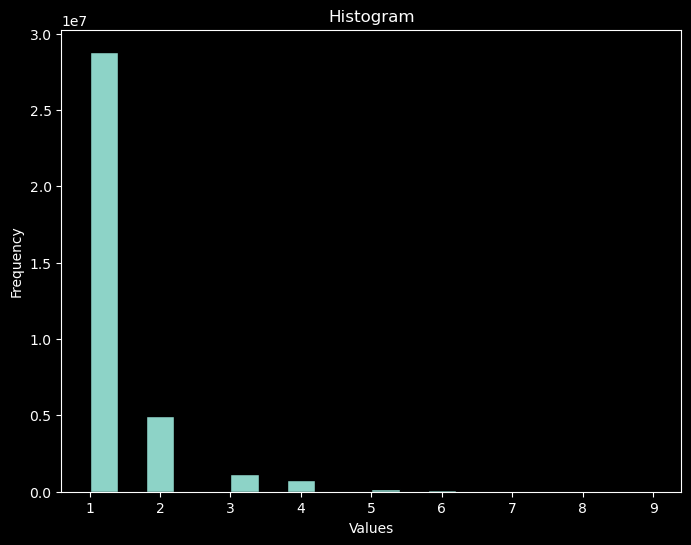

In [8]:
plt.figure(figsize=(8, 6))
plt.hist(cleaned_lf.select(pl.col("passenger_count")).collect(), bins=20, edgecolor='black')
plt.xlabel('Values')
plt.ylabel('Frequency')
plt.title('Histogram')
plt.show()

Passenger count is a discrete variable taking small integer values (1, 2, 3, …). Most trips have 1 passenger, so the median and mode are both 1, while a smaller number of trips with 2 or more passengers pull the mean up to about 1.3. This pattern (mean > median with many low values and a few higher ones) indicates that the passenger_count distribution is right‑skewed rather than symmetric. So I made a mistake with what i said earlier.

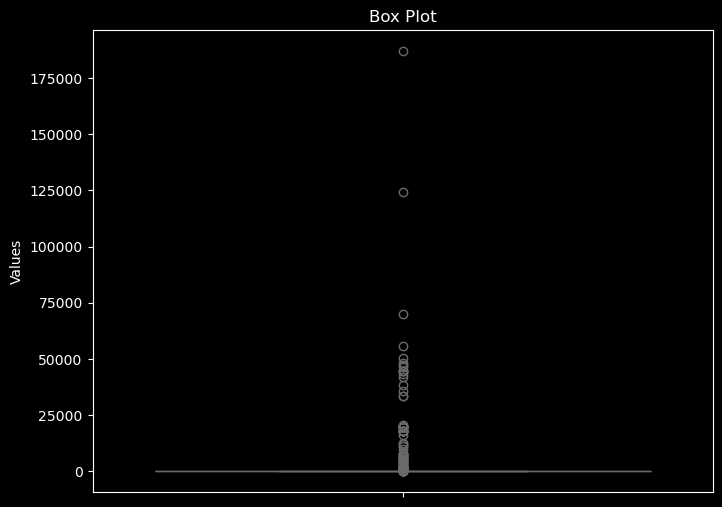

In [5]:
pdf = cleaned_lf.select("trip_distance").collect().to_pandas()
plt.figure(figsize=(8, 6))
sns.boxplot(data=pdf, y='trip_distance')
plt.ylabel('Values')
plt.title('Box Plot')
plt.show()

I don't know how i didn't realize earlier that trip distance must be having an issue! The plot clearly shows i have some massive outliers... so massive that you can barely see the "normal" trips distribution. We literally have values in thousands of miles! According to the TLC data dictionary, trip_distance is the taximeter‑reported trip distance in miles. While very long trips are theoretically possible, most NYC taxi trips are relatively short, and previous studies show a right‑skewed distribution with some outliers. In our data, we observe extremely large values (e.g., tens of thousands of miles) that are implausible given the NYC region and likely represent data errors.

In [6]:
percentile_list = [0.25, 0.50, 0.75, 0.95, 0.99]
results = pdf['trip_distance'].quantile(percentile_list)
print(results)

0.25     1.00
0.50     1.70
0.75     3.28
0.95    14.90
0.99    20.00
Name: trip_distance, dtype: float64


In our sample, 99% of NYC taxi trips are shorter than about 20 miles; therefore we treat trips with distances much larger than this as outliers or data errors and optionally filter above a data‑driven cutoff (in this case, the 99th percentile).

In [7]:
per_99 = pdf['trip_distance'].quantile(0.99)
cleaned_lf = cleaned_lf.filter((pl.col('trip_distance') <= per_99))

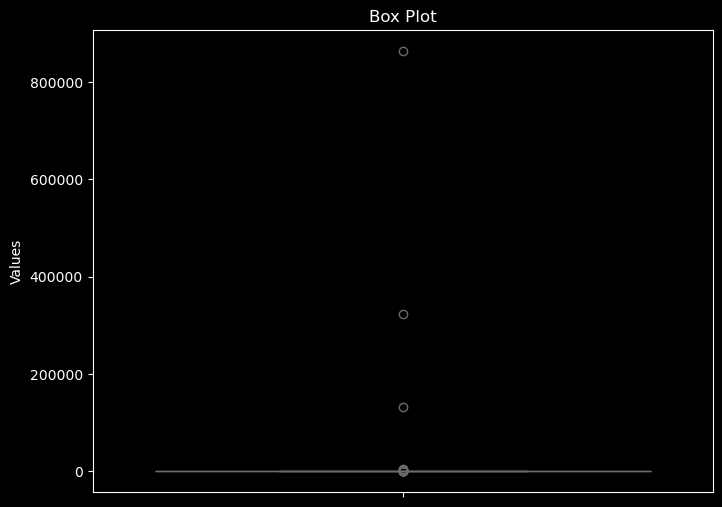

In [8]:
pdf = cleaned_lf.select("total_amount").collect().to_pandas()
plt.figure(figsize=(8, 6))
sns.boxplot(data=pdf, y='total_amount')
plt.ylabel('Values')
plt.title('Box Plot')
plt.show()

It seems to be the same story with total amount... let's check the percentiles...

In [9]:
percentile_list = [0.25, 0.50, 0.75, 0.95, 0.99]
results = pdf['total_amount'].quantile(percentile_list)
print(results)

0.25     16.450001
0.50     21.549999
0.75     31.049999
0.95     80.940002
0.99    103.500000
Name: total_amount, dtype: float64


Indeed it's most likely a case of bad data again... Let's filter this as well...

In [10]:
per_99 = pdf['total_amount'].quantile(0.99)
cleaned_lf = cleaned_lf.filter((pl.col('total_amount') <= per_99))

In [15]:
len(cleaned_lf.collect())

35323229

I guess we will have to check on the distribution of the trips in terms of frequency per day of month or month to see the effects of the rows removed and how to deal with it... we may have to do prediction of highest demand per day for a certain location.

In [11]:
cleaned_lf = cleaned_lf.with_columns(month_name = pl.col("tpep_pickup_datetime").dt.strftime("%B"))
month_grouped = (cleaned_lf.group_by("month_name").agg(pl.len().alias("month_trip_count")))
month_grouped.collect(streaming=True)

C:\Users\HP\AppData\Local\Temp\ipykernel_48712\296107376.py:3: DeprecationWarning: the `streaming` parameter was deprecated in 1.25.0; use `engine` instead.
  month_grouped.collect(streaming=True)


month_name,month_trip_count
str,u32
"""May""",3224701
"""June""",2950116
"""October""",3275460
"""November""",3035746
"""February""",2652708
…,…
"""September""",3015797
"""April""",3071816
"""March""",3080499


C:\Users\HP\AppData\Local\Temp\ipykernel_23848\2981867302.py:1: DeprecationWarning: the `streaming` parameter was deprecated in 1.25.0; use `engine` instead.
  month_trip_df = month_grouped.collect(streaming=True)


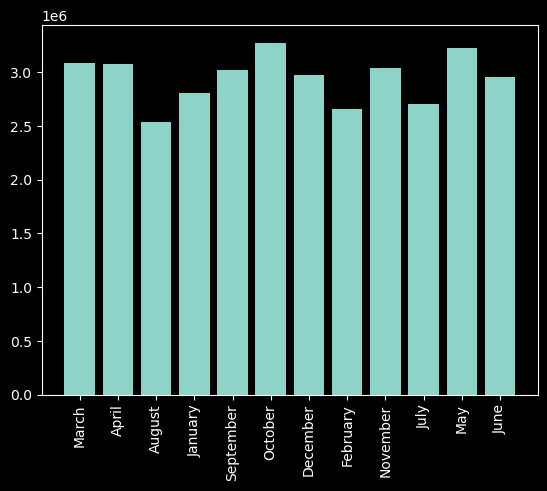

<Figure size 1200x1600 with 0 Axes>

In [17]:
month_trip_df = month_grouped.collect(streaming=True)
plt.bar(month_trip_df["month_name"], month_trip_df["month_trip_count"])
plt.xticks(rotation=90)
plt.figure(figsize=(12, 16))
plt.show()

Not too biased! We can work with this for further analysis and ML modelling...  Now let's look for some patterns/correlations in rthsps between and among columns...

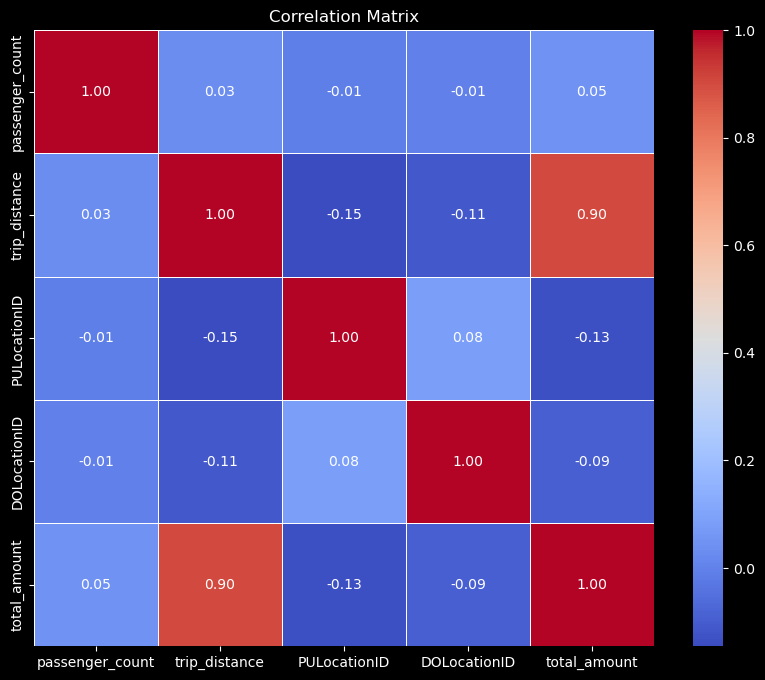

In [21]:
numeric_df = cleaned_lf.select(cs.numeric()).collect(engine="streaming")
correlation_matrix = numeric_df.corr()

# Create a heatmap to visualize the correlation matrix
plt.figure(figsize=(10, 8))
sns.heatmap(correlation_matrix.to_pandas(), annot=True, cmap='coolwarm', fmt=".2f", linewidths=0.5, xticklabels=correlation_matrix.columns, 
            yticklabels=correlation_matrix.columns)
plt.title('Correlation Matrix')
plt.show()

Well that's quite disappointing! Yeah there are some correlations but none relevant to what I want(passengers) Our only hope for now is the pickup date... I guess I'll have to split into time buckets and see the correlation

Pearson correlation (time_bucket vs passenger_count): 0.1962


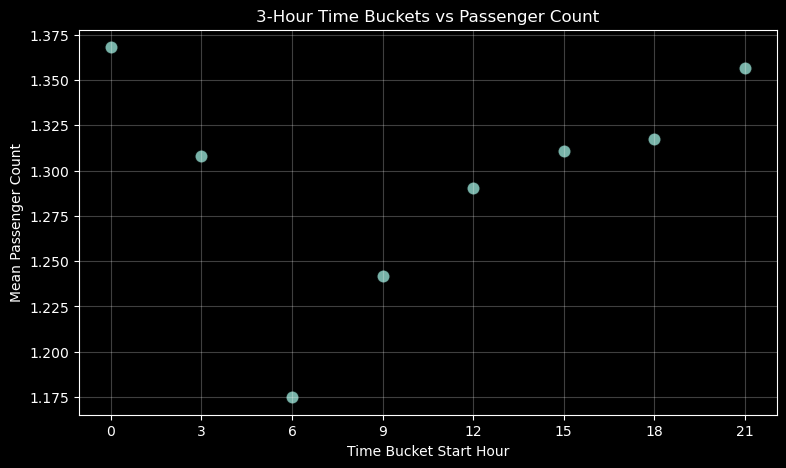

In [19]:
# Create 3-hour time buckets from pickup hour (0, 3, 6, ..., 21)
bucketed_lf = cleaned_lf.with_columns(
    ((pl.col("tpep_pickup_datetime").dt.hour() // 3) * 3).alias("time_bucket")
)

# Group by bucket and keep mean passenger count per bucket
bucket_stats = (
    bucketed_lf
    .group_by("time_bucket")
    .agg(
        pl.col("passenger_count").mean().alias("passenger_count"),
        pl.len().alias("trip_count"),
    )
    .sort("time_bucket")
)

# Pearson correlation between time_bucket and passenger_count
pearson_corr = (
    bucket_stats
    .select(pl.corr("time_bucket", "passenger_count", method="pearson").alias("pearson_corr"))
    .collect(engine="streaming")
    .item(0, 0)
)
print(f"Pearson correlation (time_bucket vs passenger_count): {pearson_corr:.4f}")

# Scatter plot: time buckets vs mean passenger count
bucket_stats_df = bucket_stats.collect(engine="streaming")
plt.figure(figsize=(9, 5))
plt.scatter(
    bucket_stats_df["time_bucket"].to_numpy(),
    bucket_stats_df["passenger_count"].to_numpy(),
    s=90,
    alpha=0.85,
    edgecolors="black",
)
plt.xticks(np.arange(0, 24, 3))
plt.xlabel("Time Bucket Start Hour")
plt.ylabel("Mean Passenger Count")
plt.title("3-Hour Time Buckets vs Passenger Count")
plt.grid(alpha=0.25)
plt.show()

a 0.2 correlation tells me that a weak, positive linear relationship exists, but it is not strong enough to suggest that this time bucket variable is a major driver of the passenger count. Maybe let's expand our grouping to "day_buckets"...

day_bucket vs passenger count: 0.4872536841882123


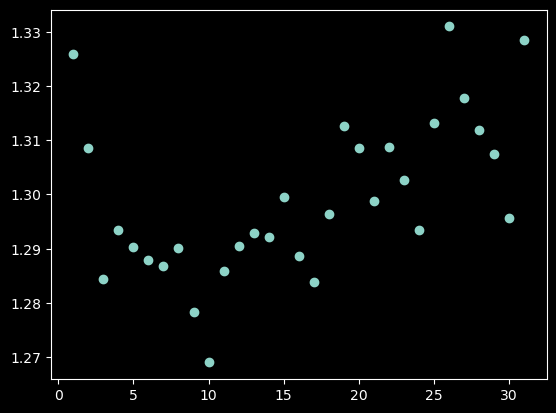

In [24]:
day_bucket_lf = cleaned_lf.with_columns(pl.col("tpep_pickup_datetime").dt.day().alias("day_bucket"))
day_bucket_lf = day_bucket_lf.group_by("day_bucket").agg(pl.col("passenger_count").mean())

pearson_corr = (day_bucket_lf.select(pl.corr("day_bucket", "passenger_count", method="pearson").alias("pearson_corr")).collect(engine="streaming").item(0,0))
print(f"day_bucket vs passenger count: {pearson_corr}")


df_day_bucket = day_bucket_lf.collect(engine="streaming")
plt.scatter(x=df_day_bucket["day_bucket"], y=df_day_bucket["passenger_count"])
plt.show()

Interesting... so there is a moderate positive correlation... what about if we group by day names?

day_bucket vs passenger count: nan


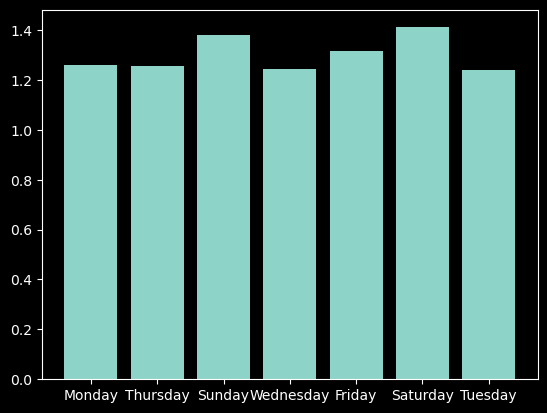

In [ ]:
day_bucket_lf = cleaned_lf.with_columns(pl.col("tpep_pickup_datetime").dt.strftime("%A").alias("day_bucket"))
day_bucket_lf = day_bucket_lf.group_by("day_bucket").agg(pl.col("passenger_count").mean())

df_day_bucket = day_bucket_lf.collect(engine="streaming")
plt.bar(df_day_bucket["day_bucket"], df_day_bucket["passenger_count"])
plt.show()

Not really much to see here... I guess we will need to start thinking of other features... However, the observation that passenger counts become higher later in the month is intriguing... I wonder why its the case... Another thing is that i am quite disappointed to find out the location of pickup doesn't move the needle in terms of demand AT ALL!

So I was thinking of "balancing out" the dataset because it kinda felt like passenger count of 1 was holding back my insights coz there is some pattern i guess but it's kind stuck on "1.x". But i also felt that would kill the structure... after all its not a bug but rather a feature of this system. So I need to do more research on how to solve this...

So beacuse of Fact about the variable which is "Discrete, non‑negative, small support (1–7), heavily skewed.", there are two options GLM count models and classification.

GLMs can be fit, but many parameters explaining higher counts will be estimated with low precision (few examples). Classification Is easier to evaluate with class imbalance tools (F1, recall, ROC/PR) The counts are tiny and easy to bin into meaningful categories, You can directly focus the objective and metrics on the rare/high-occupancy classes using class weights and suitable evaluation, and It’s conceptually and practically simpler for typical ML workflows.

Two more refined questions would be;
"For a given trip with features X, what affects the probability of a multi-passenger or high-occupancy trip, and how can I predict that?" (we may have to model probability bucket correlations with other features)

"For each zone-hour, what affects the total passenger demand, and how can I predict that demand?"
At the trip level, your demand variable is kind of underspecified (1–7, almost always 1).

If you want “real” demand forecasting, it’s often better to aggregate to a time–space unit and model total demand counts there. e.g., per hour × pickup_zone:
demand_count = total_passengers_in_zone_hour
Now demand_count might be something like 0–200, depending on data.
That is a much more natural demand count to model with Poisson/NB or even continuous regression.

If you stay at the trip level, a classification framing of occupancy is the sweetest spot between realism and tractability.

Let's see how "zone-hour counts" does vs "probability of multi-passenger". We will test both to see which most aligns with the data. We may have to do some grouping and correlation matrix...

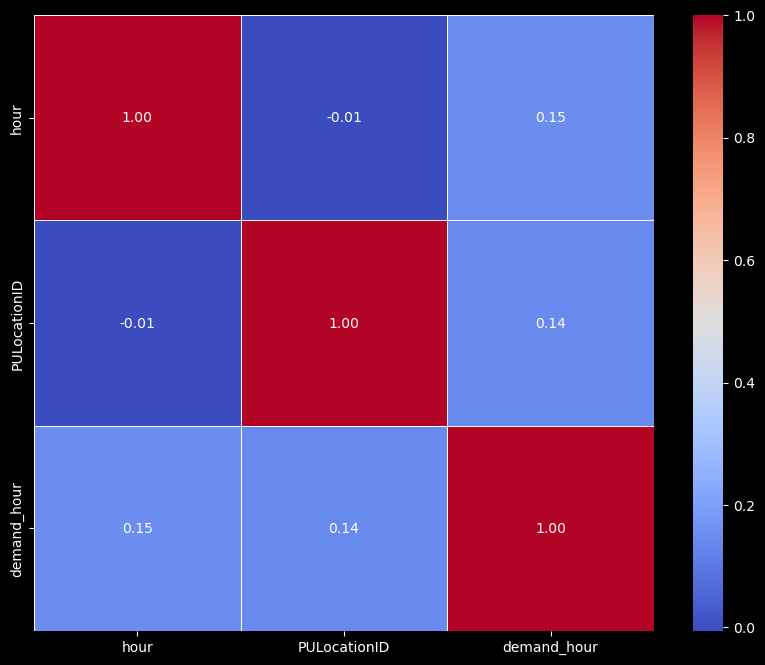

In [13]:
# Zone-hour
# group by zone and hour and sum up passneger counts for each hour for each zone in a new column
zone_hour = cleaned_lf.with_columns(pl.col("tpep_pickup_datetime").dt.hour().alias("hour"))
zone_hour = zone_hour.group_by(["hour", "PULocationID"]).agg(pl.col("passenger_count").sum().alias("demand_hour"))
correlation_matrix = zone_hour.collect().corr()
plt.figure(figsize=(10,8))
sns.heatmap(correlation_matrix.to_pandas(), annot=True, fmt=".2f", cmap="coolwarm", linewidths=0.5, xticklabels=correlation_matrix.columns, yticklabels=correlation_matrix.columns)
plt.show()

I'm thinking to myself why I even just did this!... i think let's just for the classification route... this one isn't leading where i hoped it would...

In [22]:
result_1 = cleaned_lf.select((pl.col("passenger_count") == 1).sum()/pl.len()).collect()
prob_1 = result_1.item()
result_2_plus = cleaned_lf.select((pl.col("passenger_count") > 1).sum()/pl.len()).collect()
prob_2_plus = result_2_plus.item()
print(f"Probability of 1 passenger: {result_1}")
print(f"Probability of more than 1 passenger: {result_2_plus}")

Probability of 1 passenger: shape: (1, 1)
┌─────────────────┐
│ passenger_count │
│ ---             │
│ f64             │
╞═════════════════╡
│ 0.801931        │
└─────────────────┘
Probability of more than 1 passenger: shape: (1, 1)
┌─────────────────┐
│ passenger_count │
│ ---             │
│ f64             │
╞═════════════════╡
│ 0.198069        │
└─────────────────┘


Now I have to find out what affects probability and how and also the fact that it's a binary outcome(1 vs multi)...the go-to method is logistic regression! Because It gives you coefficients that you can interpret as odds ratios... as for handling the class imbalance, we'll use class weights. 